##**TASK 5**

###Import statements

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

###Data Load

In [ ]:
df = pd.read_csv("creditcard.csv")
df = df.rename(columns={df.columns[-1]: 'Class'})
print(df.head())
print(df.shape)

                                                                35  \
36514.0  0.860002 -0.839978 2.034260  1.925888 -1.749583  0.916224   
        -1.308242  0.954849 1.671037  1.845146 -1.162109  0.489589   
         1.057902 -0.700797 0.353021 -0.445110 -1.261033 -1.186715   
         1.258270  0.059820 0.418057  0.768841 -0.313122 -0.298726   
36515.0  1.159038 -1.795929 0.707623 -0.834650 -2.085498 -0.325204   

                                                          -0.0992668447658745  \
36514.0  0.860002 -0.839978 2.034260  1.925888 -1.749583            -1.321855   
        -1.308242  0.954849 1.671037  1.845146 -1.162109            -0.818610   
         1.057902 -0.700797 0.353021 -0.445110 -1.261033            -0.146030   
         1.258270  0.059820 0.418057  0.768841 -0.313122            -0.072501   
36515.0  1.159038 -1.795929 0.707623 -0.834650 -2.085498            -1.126387   

                                                          -0.0749779487678777  \
36514.0  0.

###Fraud Distribution Plot

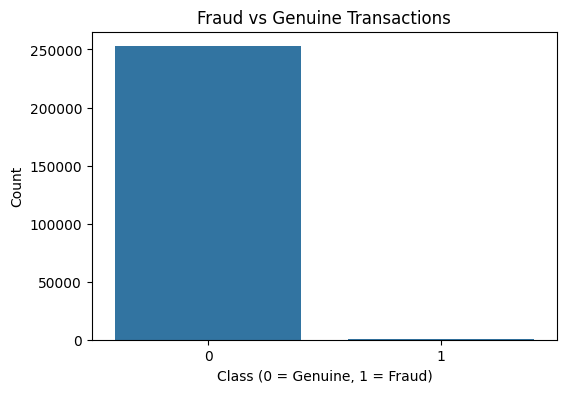

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(
    x="Class",
    data=df
)
plt.title("Fraud vs Genuine Transactions")
plt.xlabel("Class (0 = Genuine, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

###Model Training and Prediction

In [ ]:
X = df.drop("Class", axis=1)
y = df["Class"]
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
model = LogisticRegression(
    max_iter=1000
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

###Accuracy Analysis

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy*100:.2f}%")
print("\nClassification Report\n")
print(classification_report(y_test, y_pred))


Accuracy: 99.94%

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     50528
           1       0.93      0.69      0.79        78

    accuracy                           1.00     50606
   macro avg       0.97      0.85      0.90     50606
weighted avg       1.00      1.00      1.00     50606



###Confusion Matrix

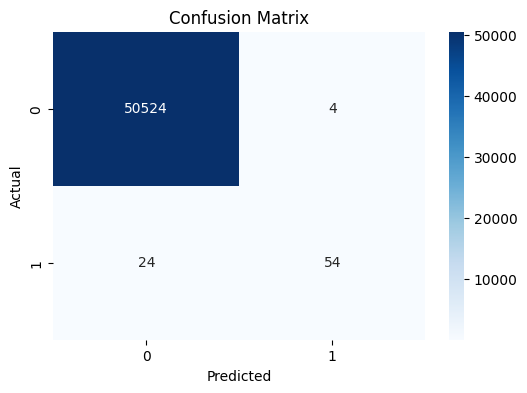

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

###Handling Class Imbalance (Oversampling)

In [ ]:
from sklearn.utils import resample
fraud = df[df["Class"] == 1]
genuine = df[df["Class"] == 0]
fraud_oversampled = resample(
    fraud,
    replace=True,
    n_samples=len(genuine),
    random_state=42
)
balanced_df = pd.concat(
    [genuine, fraud_oversampled]
)
print(balanced_df["Class"].value_counts())

Class
0    252637
1    252637
Name: count, dtype: int64


###Fraud Distribution After Oversampling

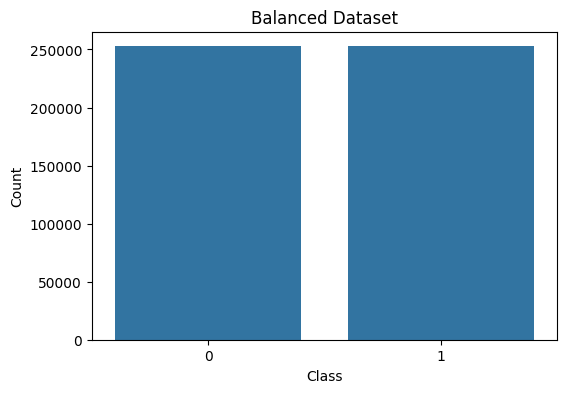

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(
    x="Class",
    data=balanced_df
)
plt.title("Balanced Dataset")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()